# The Drawdown You Were Promised — a quantitative teardown 🔬
### Exact discretely-sampled GBM · ex-ante coverage of the MDD band · bootstrap and GARCH-t challengers · the multiplier and its stability

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Companion to the [notebook for the curious](01_for_the_curious.ipynb). §1 shows the simulation
reproduces Magdon-Ismail et al. (2004) and why sampling frequency matters; §3 is the
pre-registered test; §4 decomposes the failure; §5 prices the fix; §7 checks the machinery on a
synthetic tape where the answer is known.

> ⚠️ **Not investment advice.** Real numbers are from `quantlab.bundled` tapes (SHA-256 pinned),
> as-of 2022-11-30; the fingerprinted run is [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
warnings.filterwarnings("ignore")
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from promised import data, strategy as st
print("real tapes available:", data.have_real(), "| as-of", data.AS_OF)

real tapes available: True | as-of 2022-11-30


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | Written down from the preceding years only, the Gaussian 95% drawdown band was breached in 1-year non-overlapping windows on the S&P 500 **22%** (6/27, p = 0.002), the Nasdaq **13%** (2/15, p = 0.171) and the Fama-French market **15%** (12/81, p = 0.001) — against a promised 5%, and **16%** pooled. The machinery is calibrated where it should be (5.8% on an i.i.d. Gaussian tape), so the failure belongs to the tape: the median year delivered only **0.68×** the promised mean drawdown, yet the bad years overran the 95th percentile 3.3× as often as promised. Even with the whole tape's mu and sigma in hindsight the S&P 500 band broke in 15% of years. Twenty survivor stocks — a floor — broke it in 12% of stock-years. |
| **Tradability** | Mirage | Scaling the Gaussian takes **k95 = 1.63×** pooled, but the multiplier a risk manager would have needed wanders from 1.03 to 1.92 across tapes and eras (max/min 1.87, outside the pre-registered 1.5). Neither the block bootstrap (15%) nor GARCH-t (14%) restored coverage on all three tapes. The cheapest partial repair was a humbler mean — drift set to zero, 8% pooled, k95 1.19 — at the price of over-promising at 5–10 years. No return stream, so Investable is not on offer. |

> **In one sentence:** Fed the trailing mean and volatility, the Gaussian drawdown promise was broken in 16% of years instead of 5% — knowing mu and sigma is not knowing drawdown risk — and no fixed multiplier (it wandered from 1.0× to 1.9×) and no off-the-shelf model repairs it.

## 0 · Hypotheses and the pre-registered rule

- **H₁ (coverage).** With mu, sigma estimated on the preceding 5 years (10 for monthly), the
  1-year 95% MDD band of a discretely-sampled GBM is breached more than 5% of the time —
  exact one-sided binomial test on non-overlapping calendar windows, per tape. **Real** needs
  p < 0.05 on two of the three index tapes *and* a calibrated synthetic null.
- **H₂ (decomposition).** The failure survives handing the model the whole-tape moments
  (shape/state, not estimation).
- **H₃ (challengers).** A stationary block bootstrap or a GARCH(1,1)-t restores coverage on all
  three tapes (p ≥ 0.05 and rate ≤ 10%).
- **H₄ (multiplier).** The required factor k95 on the Gaussian 95th percentile is stable
  (max/min ≤ 1.5 across tapes and halves). **Fragile** if H₃ or H₄ holds; else **Mirage**.

## 1 · The promise and the discretisation

                n_steps  mean  median   q95   q99  mean_log  continuous_formula_log
steps_per_year                                                                     
12                   12 0.136   0.125 0.262 0.327     0.150                   0.201
52                   52 0.158   0.145 0.283 0.347     0.175                   0.201
252                 252 0.169   0.157 0.295 0.359     0.189                   0.201
1008               1008 0.174   0.163 0.295 0.350     0.195                   0.201
4032               4032 0.176   0.166 0.292 0.351     0.197                   0.201


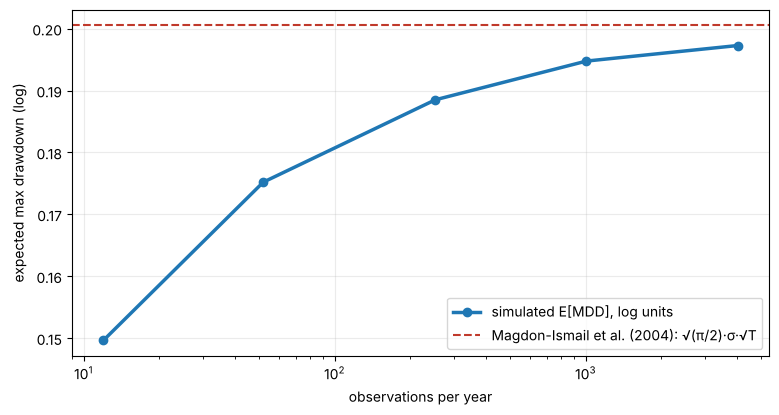

In [2]:
d = st.discretisation_table(0.0, 0.16, 1.0, steps_per_year=(12, 52, 252, 252 * 4, 252 * 16), n_sims=3000)
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.semilogx(d.index, d["mean_log"], "o-", lw=2.5, label="simulated E[MDD], log units")
ax.axhline(d["continuous_formula_log"].iloc[0], color="#c0392b", ls="--",
           label="Magdon-Ismail et al. (2004): √(π/2)·σ·√T")
ax.set_xlabel("observations per year"); ax.set_ylabel("expected max drawdown (log)")
ax.legend(); plt.show()

> 💡 **In plain words.** The exact simulation converges on the textbook formula
> (gap 1.1% at 16 steps a day). But a monthly-marked account sees ~20%
> less drawdown than a daily-marked one: the formula must be matched to the marking frequency,
> so every promise below is simulated at the tape's own frequency.

## 2 · The tapes

In [3]:
tapes = {t: data.load_tape(t) for t in data.INDEX_TAPES}
LB = {"sp500": 5, "nasdaq": 5, "ff_market": 10}
rows = []
for t, r in tapes.items():
    ppy = data.PERIODS_PER_YEAR[t]
    rows.append({"tape": t, "label": data.LABELS[t], "first": r.index[0].date(),
                 "last": r.index[-1].date(), "n": len(r), "mu_ann (log)": r.mean() * ppy,
                 "vol_ann": r.std() * np.sqrt(ppy), "excess kurtosis": r.kurt(),
                 "sha": data.sha_pin(t), "fingerprint": data.fingerprint(r)})
pd.DataFrame(rows).set_index("tape")

,label,first,last,n,mu_ann (log),vol_ann,excess kurtosis,sha,fingerprint
tape,,,,,,,,,
sp500,"S&P 500 price index, daily (skfolio 1.8.1)",1990-01-03,2022-11-30,8293,0.074,0.183,10.651,894c34431c28,8b8e9cb44470
nasdaq,"Nasdaq Composite price index, daily (arch)",1999-01-05,2018-12-31,5030,0.055,0.253,5.433,b2009535343e,3e1d2effd37e
ff_market,"Fama-French US market total return, monthly (a...",1926-07-31,2018-11-30,1109,0.095,0.184,6.992,f23436727b01,268a3ac2660b


## 3 · The ex-ante test — non-overlapping calendar windows

For each window the five models are estimated on the preceding years only; 4,000 paths for the
Gaussians at 1–3 years. (5- and 10-year windows are in `docs/results.md`; with 1–16 windows
each they are anecdotes.)

In [4]:
cov = pd.concat([st.coverage(r, t, data.PERIODS_PER_YEAR[t], (1, 3), LB[t], st.MODELS, n_sims=4000)
                 for t, r in tapes.items()], ignore_index=True)
summ = st.summarise(cov)
summ[summ["model"] == "gauss"][["tape", "horizon", "n", "breaches95", "rate95", "p_greater",
                                "rate99", "median_ratio_mean", "mean_pit", "k95"]]

,tape,horizon,n,breaches95,rate95,p_greater,rate99,median_ratio_mean,mean_pit,k95
0,sp500,1,27,6,0.222,0.002,0.074,0.773,0.423,1.528
5,sp500,3,9,3,0.333,0.008,0.222,0.979,0.509,1.334
10,nasdaq,1,15,2,0.133,0.171,0.067,0.540,0.287,1.507
15,nasdaq,3,5,1,0.200,0.226,0.000,0.481,0.334,0.997
20,ff_market,1,81,12,0.148,0.001,0.099,0.680,0.405,1.577
25,ff_market,3,27,5,0.185,0.010,0.111,0.729,0.449,1.734


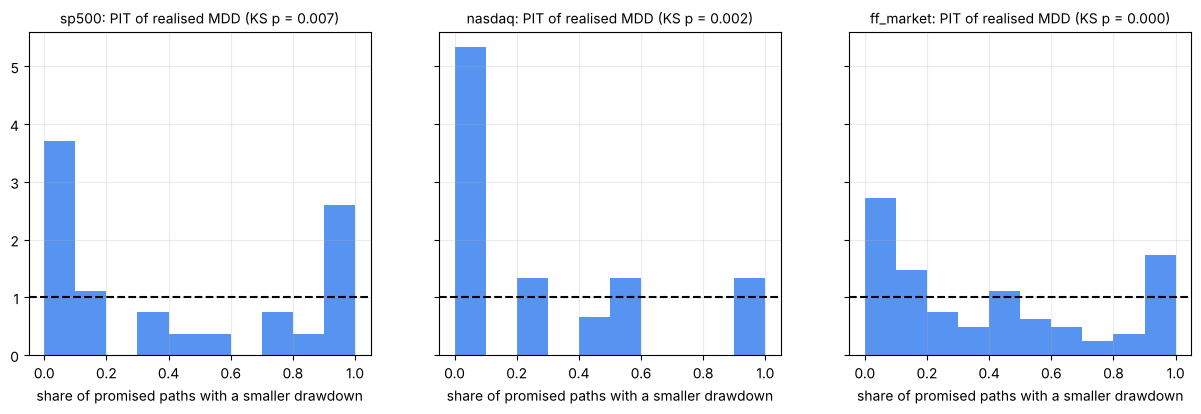

In [5]:
g = cov[(cov["model"] == "gauss") & (cov["horizon"] == 1)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, t in zip(axes, data.INDEX_TAPES):
    p = g[g["tape"] == t]["pit"]
    ax.hist(p, bins=10, range=(0, 1), color="#1f6feb", alpha=0.75, density=True)
    ax.axhline(1, color="k", ls="--")
    ax.set_title(f"{t}: PIT of realised MDD (KS p = {st.ks_uniform_pit(p):.3f})", fontsize=10)
    ax.set_xlabel("share of promised paths with a smaller drawdown")
plt.show()

> 💡 **In plain words.** If the promise were right, these histograms would be flat. They
> pile up on the **left** (most years calmer than promised) *and* carry excess mass at the far
> right (the breaches). Pooled 1-year breach rate 16% of 123 windows,
> 3.3× the nominal rate; median realised/promised mean 0.68. That
> combination is a shape failure — the right scale would not fix it.

### 3.1 Overlapping windows, block-bootstrap inference

In [6]:
ov = []
for t, r in tapes.items():
    c = st.coverage(r, t, data.PERIODS_PER_YEAR[t], (3, 5), LB[t], ("gauss",), step_years=1, n_sims=2000)
    for H, gh in c.groupby("horizon"):
        b = st.block_bootstrap_rate(gh.sort_values("start")["breach95"].to_numpy(), block=H)
        ov.append({"tape": t, "horizon": H, **b})
pd.DataFrame(ov)

,tape,horizon,rate,lo,hi,p_greater,n
0,sp500,3,0.400,0.200,0.600,0.002,25
1,sp500,5,0.348,0.130,0.565,0.025,23
2,nasdaq,3,0.154,0.000,0.385,0.229,13
3,nasdaq,5,0.091,0.000,0.273,0.072,11
4,ff_market,3,0.241,0.139,0.354,0.004,79
5,ff_market,5,0.338,0.221,0.519,0.003,77


> 💡 **In plain words.** Stepping windows one year at a time gives more of them, but they
> share most of their path; the moving-block bootstrap (blocks of H windows) keeps the shared
> crises together so the interval is honest.

## 4 · What is missing? Mean, shape, or volatility state

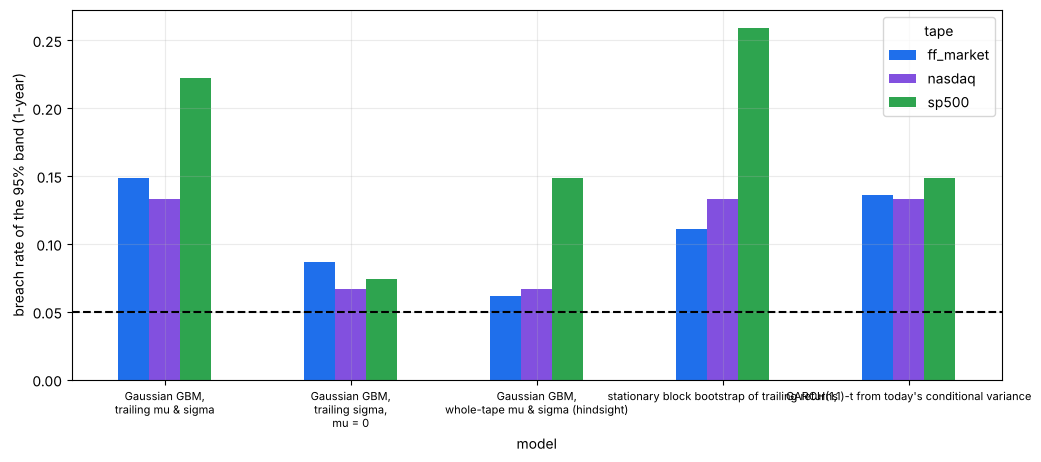

,tape,model,n,rate95,p_greater,p_less,median_ratio_mean,k95
0,sp500,gauss,27,0.222,0.002,1.000,0.773,1.528
1,sp500,gauss_mu0,27,0.074,0.394,0.850,0.661,1.223
2,sp500,gauss_oracle,27,0.148,0.044,0.990,0.636,1.155
3,sp500,boot,27,0.259,0.000,1.000,0.923,1.702
4,sp500,garch_t,27,0.148,0.044,0.990,1.089,1.264
5,nasdaq,gauss,15,0.133,0.171,0.964,0.540,1.507
6,nasdaq,gauss_mu0,15,0.067,0.537,0.829,0.548,1.119
7,nasdaq,gauss_oracle,15,0.067,0.537,0.829,0.624,0.790
8,nasdaq,boot,15,0.133,0.171,0.964,0.558,1.660
9,nasdaq,garch_t,15,0.133,0.171,0.964,1.149,1.422


In [7]:
one = cov[cov["horizon"] == 1]
tab = st.summarise(one)[["tape", "model", "n", "rate95", "p_greater", "p_less", "median_ratio_mean", "k95"]]
fig, ax = plt.subplots(figsize=(12, 4.8))
piv = tab.pivot(index="model", columns="tape", values="rate95").loc[list(st.MODELS)]
piv.plot.bar(ax=ax, rot=0, color=["#1f6feb", "#8250df", "#2ea44f"])
ax.axhline(0.05, color="k", ls="--", lw=1.5)
ax.set_ylabel("breach rate of the 95% band (1-year)")
ax.set_xticklabels([st.MODEL_LABELS[m].replace(", ", ",\n") for m in piv.index], fontsize=8)
plt.show()
tab

> 💡 **In plain words.** Three separate failures, sized:
> * **The trailing mean.** Setting mu = 0 drops the pooled breach rate to 8%. A
>   5-year trailing mean is highest right after long rallies, i.e. right before the falls.
> * **Shape and regime.** Even with whole-tape (hindsight) moments the S&P 500 band broke in
>   15% of years.
> * **Neither challenger is a cure.** The bootstrap (15% pooled) replays the
>   lookback's calm; GARCH-t (14%) starts from today's variance but mean-reverts it
>   within months, so it cannot anticipate a regime that has not started.

## 5 · The multiplier, and whether it is stable

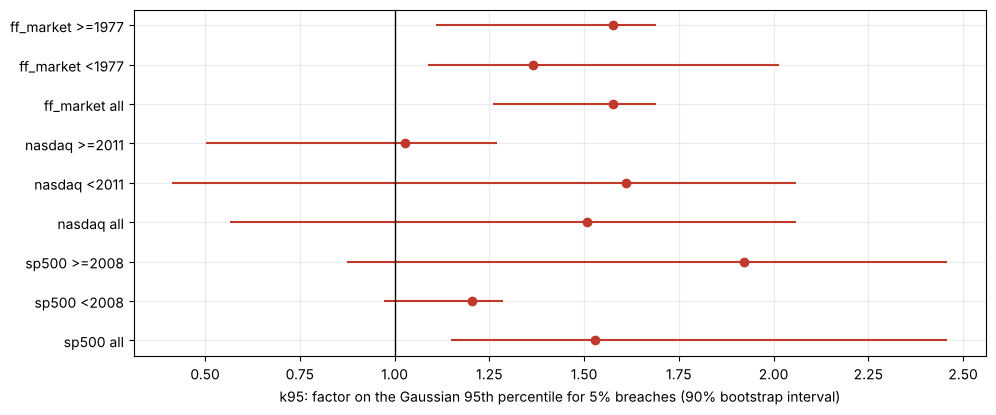

max/min across tapes and eras: 1.87 (pre-registered stability bar 1.5)


,tape,era,n,k95,lo,hi
0,sp500,all,27,1.528,1.148,2.459
1,sp500,<2008,13,1.203,0.972,1.286
2,sp500,>=2008,14,1.921,0.876,2.459
3,nasdaq,all,15,1.507,0.565,2.059
4,nasdaq,<2011,7,1.610,0.414,2.059
5,nasdaq,>=2011,8,1.028,0.503,1.270
6,ff_market,all,81,1.577,1.260,1.690
7,ff_market,<1977,40,1.366,1.088,2.015
8,ff_market,>=1977,41,1.577,1.110,1.690


In [8]:
g1 = one[one["model"] == "gauss"].copy()
rows = []
for t, gt in g1.groupby("tape", sort=False):
    yrs = np.sort(gt["start"].unique()); cut = yrs[len(yrs) // 2]
    for lab, ge in (("all", gt), (f"<{cut}", gt[gt["start"] < cut]), (f">={cut}", gt[gt["start"] >= cut])):
        lo, hi = st.multiplier_ci(ge["realised"], ge["p_q95"], n_boot=500)
        rows.append({"tape": t, "era": lab, "n": len(ge),
                     "k95": st.multiplier(ge["realised"], ge["p_q95"]), "lo": lo, "hi": hi})
mt = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(11, 4.5))
y = np.arange(len(mt))
ax.errorbar(mt["k95"], y, xerr=[mt["k95"] - mt["lo"], mt["hi"] - mt["k95"]], fmt="o", color="#c0392b")
ax.axvline(1, color="k", lw=1); ax.set_yticks(y); ax.set_yticklabels(mt["tape"] + " " + mt["era"])
ax.set_xlabel("k95: factor on the Gaussian 95th percentile for 5% breaches (90% bootstrap interval)")
plt.show()
print(f"max/min across tapes and eras: {mt['k95'].max() / mt['k95'].min():.2f} (pre-registered stability bar 1.5)")
mt

> 💡 **In plain words.** A pooled factor of 1.63× would have worked on
> average, but the era-level factors span 1.03–1.92× (ratio
> 1.87), and the intervals are wide because a 95th percentile of 7–40 windows is
> mostly its largest one or two observations. A multiplier calibrated on 1995–2007 would have
> been blown through in 2008–2021.

## 6 · Twenty survivors

Single names, 1-year windows, 5-year lookback. **Survivor sample**: realised drawdowns are a
lower bound; breach rates a floor.

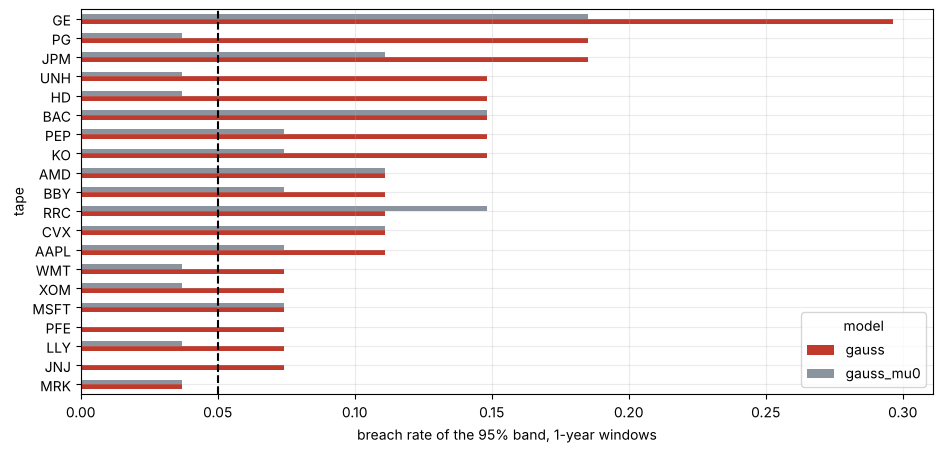

model
gauss       0.122
gauss_mu0   0.072


In [9]:
S = data.load_stocks()
sc = pd.concat([st.coverage(S[c].dropna(), c, 252, (1,), 5, ("gauss", "gauss_mu0"), n_sims=2000)
                for c in S.columns], ignore_index=True)
per = sc.pivot_table(index="tape", columns="model", values="breach95", aggfunc="mean").sort_values("gauss")
fig, ax = plt.subplots(figsize=(11, 5))
per.plot.barh(ax=ax, color=["#c0392b", "#8b949e"])
ax.axvline(0.05, color="k", ls="--"); ax.set_xlabel("breach rate of the 95% band, 1-year windows")
plt.show()
print(sc.groupby("model")["breach95"].mean().round(3).to_string())

> 💡 **In plain words.** Across 540 stock-years the plug-in broke its band in
> 12% (k95 1.33, year-clustered interval 1.03–1.60).
> These are the names that *survived* to 2022 — the ones whose drawdown went to 100% are not
> here, so the true single-name failure is worse.

## 7 · Synthetic calibration — where the truth is known

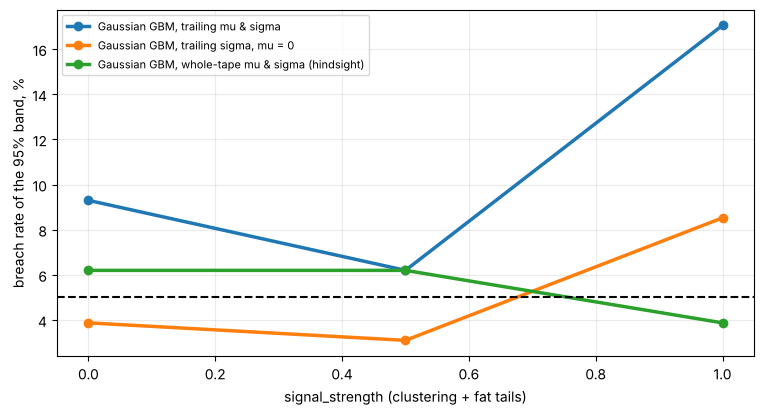

,signal_strength,model,n,rate95
0,0.000,gauss,129,0.093
1,0.000,gauss_mu0,129,0.039
2,0.000,gauss_oracle,129,0.062
3,0.500,gauss,129,0.062
4,0.500,gauss_mu0,129,0.031
5,0.500,gauss_oracle,129,0.062
6,1.000,gauss,129,0.171
7,1.000,gauss_mu0,129,0.085
8,1.000,gauss_oracle,129,0.039


In [10]:
rows = []
for s in (0.0, 0.5, 1.0):
    c = st.synthetic_coverage(s, n_years=50, models=("gauss", "gauss_mu0", "gauss_oracle"),
                              n_tapes=3, n_sims=2000)
    for m, gm in c.groupby("model"):
        rows.append({"signal_strength": s, "model": m, "n": len(gm), "rate95": gm["breach95"].mean()})
sy = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4.5))
for m, gm in sy.groupby("model"):
    ax.plot(gm["signal_strength"], gm["rate95"] * 100, "o-", lw=2.5, label=st.MODEL_LABELS[m])
ax.axhline(5, color="k", ls="--"); ax.set_xlabel("signal_strength (clustering + fat tails)")
ax.set_ylabel("breach rate of the 95% band, %"); ax.legend(fontsize=8); plt.show()
sy

> 💡 **In plain words.** On an i.i.d. Gaussian tape (signal_strength 0) the formula with
> the true moments breaches about 5% (5.8% in the full run), and estimating the
> moments from five years costs little (7.7%). Plant clustering and t(4) tails at
> the *same* mean and variance and the plug-in jumps to 15.7% — the same
> direction and size as the real tapes. The hindsight Gaussian *under*-breaches there because,
> under heavy clustering, the typical year's volatility sits well below the unconditional one.

## 8 · Robustness and limits

- **Lookback.** S&P 500 plug-in breach rates are 14–22% for 3/5/10-year and
  expanding lookbacks. On Fama-French the expanding-window plug-in falls to 7% (p = 0.28)
  — a ninety-year average mean is far less cheerful than a five-year one, which is the
  trailing-mean story again. The Nasdaq never rejects on its own (15 windows, and the dot-com
  crash precedes its first window).
- **Overlap.** The three index tapes share 1999–2018; the rule asks for two of three rather than
  pooling p-values.
- **Price indices** for S&P 500 and Nasdaq (no dividends); total return for Fama-French.

## 9 · Going further

- **Regime-switching volatility** (Hamilton-style) is the natural next challenger: GARCH
  mean-reverts too fast to know a regime, a Markov switch may not.
- **Implied volatility** as the scale (VIX is bundled for 2014–2019 only) would test whether
  the market's own forecast does better than a trailing one.
- **Conditional Drawdown-at-Risk** (Chekhlov, Uryasev & Zabarankin) as a risk budget: does the
  expected shortfall of the MDD distribution suffer the same coverage failure?
- **Contribute** a tape: the coverage test is two lines per series in `examples/verify.py`.